# preRA cohort scRNA analysis in Python memory B cells

- CertPro data

### Contents


In [2]:
import glob
import os

import anndata
import decoupler as dc
import h5py
import hisepy as hp
import numpy as np
import pandas as pd
import sc_toolbox as sct
import scanpy as sc
import scipy.sparse as scs
import seaborn as sns
from matplotlib import pyplot as plt
from scipy.stats import median_abs_deviation

In [3]:
import matplotlib

matplotlib.rcParams["pdf.fonttype"] = 42

In [4]:
# define some color patterns for plotting
nejm_color = [
    "#BC3C29FF",
    "#0072B5FF",
    "#E18727FF",
    "#20854EFF",
    "#7876B1FF",
    "#6F99ADFF",
    "#FFDC91FF",
    "#EE4C97FF",
]
jama_color = [
    "#374E55FF",
    "#DF8F44FF",
    "#00A1D5FF",
    "#B24745FF",
    "#79AF97FF",
    "#6A6599FF",
    "#80796BFF",
]

In [5]:
# define working path
data_path = "/home/workspace/data/ra_longitudinal/scrna/certPro/"
fig_path = "/home/workspace/private/ra-cohort-ide/ALTRA_manuscript/Bmem/figures/"
meta_path = "/home/workspace/github/ra-longitudinal/metadata/"
output_path = (
    "/home/workspace/private/ra-cohort-ide/ALTRA_manuscript/Bmem/Bmem_results/"
)
# os.mkdir(output_path)
# define a project name
proj_name = "ALTRA_scRNA_Bmem_certPro_"
# sc.set_figure_params(fig_path)
sc.settings.figdir = fig_path
sc.settings.autosave = False
sc.set_figure_params(vector_friendly=True, dpi_save=300)

In [10]:
def save_plot(fig, ax, save):
    """
    Save a matplotlib figure to a file.

    Parameters:
    - fig: The matplotlib figure object to be saved.
    - ax: The matplotlib axes object associated with the figure.
    - save: The file path to save the figure to.

    Raises:
    - ValueError: If any of the input parameters are None.

    Returns:
    - None
    """
    if save is not None:
        if ax is not None:
            if fig is not None:
                fig.savefig(save, bbox_inches="tight")
            else:
                raise ValueError("fig is None, cannot save figure.")
        else:
            raise ValueError("ax is None, cannot save figure.")


def filter_limits(df, sign_limit=None, lFCs_limit=None):
    """
    Filter a DataFrame based on sign and log fold change limits.

    Parameters:
    df (DataFrame): The input DataFrame to be filtered.
    sign_limit (float, optional): The limit for p-values. Default is None.
    lFCs_limit (float, optional): The limit for log fold changes. Default is None.

    Returns:
    DataFrame: The filtered DataFrame based on the specified limits.
    """

    # Define limits if not defined
    if sign_limit is None:
        sign_limit = np.inf
    if lFCs_limit is None:
        lFCs_limit = np.inf

    # Filter by absolute value limits
    msk_sign = df["pvals"] < np.abs(sign_limit)
    msk_lFCs = np.abs(df["logFCs"]) < np.abs(lFCs_limit)
    df = df.loc[msk_sign & msk_lFCs]

    return df


def plot_volcano_df(
    data,
    x,
    y,
    top=5,
    genes=None,
    sign_thr=0.05,
    lFCs_thr=0.5,
    sign_limit=None,
    lFCs_limit=None,
    color_pos="#D62728",
    color_neg="#1F77B4",
    color_null="gray",
    figsize=(7, 5),
    dpi=100,
    ax=None,
    return_fig=False,
    save=None,
):
    """
    Plot logFC and p-values from a long formated data-frame.

    Parameters
    ----------
    data : pd.DataFrame
        Results of DEA in long format.
    x : str
        Column name of data storing the logFCs.
    y : str
        Columns name of data storing the p-values.
    top : int
        Number of top differentially expressed features to show.
    sign_thr : float
        Significance threshold for p-values.
    lFCs_thr : float
        Significance threshold for logFCs.
    sign_limit : float
        Limit of p-values to plot in -log10.
    lFCs_limit : float
        Limit of logFCs to plot in absolute value.
    color_pos: str
        Color to plot significant positive genes.
    color_neg: str
        Color to plot significant negative genes.
    color_null: str
        Color to plot rest of the genes.
    figsize : tuple
        Figure size.
    dpi : int
        DPI resolution of figure.
    ax : Axes, None
        A matplotlib axes object. If None returns new figure.
    return_fig : bool
        Whether to return a Figure object or not.
    save : str, None
        Path to where to save the plot. Infer the filetype if ending on {``.pdf``, ``.png``, ``.svg``}.

    Returns
    -------
    fig : Figure, None
        If return_fig, returns Figure object.
    """
    import numpy as np
    from adjustText import adjust_text

    # # Load plotting packages
    # plt = check_if_matplotlib()
    # at = check_if_adjustText()
    # Transform sign_thr
    sign_thr = -np.log10(sign_thr)

    # Extract df
    df = data.copy()
    df["logFCs"] = df[x]
    df["pvals"] = -np.log10(df[y])

    # Filter by limits
    df = filter_limits(df, sign_limit=sign_limit, lFCs_limit=lFCs_limit)

    # Define color by up or down regulation and significance
    df["weight"] = color_null
    up_msk = (df["logFCs"] >= lFCs_thr) & (df["pvals"] >= sign_thr)
    dw_msk = (df["logFCs"] <= -lFCs_thr) & (df["pvals"] >= sign_thr)
    df.loc[up_msk, "weight"] = color_pos
    df.loc[dw_msk, "weight"] = color_neg

    # Plot
    fig = None
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=dpi)
    df.plot.scatter(x="logFCs", y="pvals", c="weight", sharex=False, ax=ax)
    ax.set_axisbelow(True)

    # Draw sign lines
    ax.axhline(y=sign_thr, linestyle="--", color="black")
    ax.axvline(x=lFCs_thr, linestyle="--", color="black")
    ax.axvline(x=-lFCs_thr, linestyle="--", color="black")

    if genes is None:
        # Plot top sign features
        signs = df[up_msk | dw_msk].sort_values("pvals", ascending=False)
        signs = signs.iloc[:top]
    else:
        signs = df[up_msk | dw_msk].sort_values("pvals", ascending=False)
        signs = signs.loc[signs.index.isin(genes)]
    # Add labels
    ax.set_ylabel("-log10(p.adj)")
    ax.set_xlabel("Log2 fold change")
    texts = []
    for x, y, s in zip(signs["logFCs"], signs["pvals"], signs.index):
        texts.append(ax.text(x, y, s))
    if len(texts) > 0:
        adjust_text(texts, arrowprops=dict(arrowstyle="-", color="black"), ax=ax)

    save_plot(fig, ax, save)

    if return_fig:
        return fig


# define helper function
def get_marker_expression_stats(adata, markers, cluster_col):
    """
    Calculate mean expression and percent expressing cells for given markers per cluster.

    Parameters
    ----------
    adata : AnnData
        AnnData object with expression data.
    markers : list of str
        List of marker gene names.
    cluster_col : str
        Column in adata.obs to group by (e.g., cluster label).

    Returns
    -------
    pd.DataFrame
        DataFrame with columns: cluster_col, gene, mean_expression, percent_expressing
    """
    # Check if cluster_col exists in adata.obs
    if cluster_col not in adata.obs.columns:
        raise ValueError(
            f"'{cluster_col}' not found in adata.obs columns: {list(adata.obs.columns)}"
        )

    # Extract marker expression and cluster info into a DataFrame
    df = sc.get.obs_df(adata, keys=markers + [cluster_col])

    # Define percent expressing function
    def percent_expressing(x):
        return np.mean(x > 0) * 100

    # Aggregate: get mean and percent expressing for each marker per cluster
    agg_df = (
        df.groupby(cluster_col)[markers].agg([percent_expressing, "mean"]).reset_index()
    )

    # If cluster_col is not a column, reset index to make it a column
    if cluster_col not in agg_df.columns:
        agg_df = agg_df.reset_index()

    # Reshape to tidy format:
    # - set cluster_col as index
    # - melt to long format
    # - rename columns for clarity
    # - pivot so each row is cluster/gene, columns are metrics
    result = (
        agg_df.set_index(cluster_col)
        .melt(value_name="value", ignore_index=False)
        .rename(columns={"variable_0": "gene", "variable_1": "metric"})
        .reset_index()
        .pivot(index=[cluster_col, "gene"], columns="metric", values="value")
        .reset_index()
    )

    # Rename columns for clarity
    result = result.rename(
        columns={"mean": "mean_expression", "percent_expressing": "percent_expressing"}
    )

    # Remove index name if present
    result.index.name = None

    return result

In [7]:
# set fig size
plt.rcParams["figure.figsize"] = [10, 8]

# load data


In [3]:
# download data
hp.cache_files(["609f7543-d4d5-41e9-a3d2-8e50c3e7c61d"])

['/home/workspace/input/569004694/UCSDCU_Y4/609f7543-d4d5-41e9-a3d2-8e50c3e7c61d/ALTRA_certPro_scRNA_141_samples_combined_adata.h5ad']

In [11]:
# load the deep clean data
joint_adata_fl = sc.read_h5ad(
    "/home/workspace/input/569004694/UCSDCU_Y4/609f7543-d4d5-41e9-a3d2-8e50c3e7c61d/ALTRA_certPro_scRNA_141_samples_combined_adata.h5ad"
)

/home/workspace/environment/py_scrna/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [12]:
joint_adata_fl

AnnData object with n_obs × n_vars = 2059581 × 33538
    obs: 'barcodes', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'well_id', 'sample.sampleKitGuid', 'cohort.cohortGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.race', 'subject.ethnicity', 'subject.birthYear', 'sample.visitName', 'sample.drawDate', 'sample.diseaseStatesRecordedAtVisit', 'sample.daysSinceFirstVisit', 'file.id', 'subset_grp', 'predicted_doublet', 'doublet_score', 'AIFI_L1', 'AIFI_L1_score', 'AIFI_L2', 'AIFI_L2_score', 'AIFI_L3', 'AIFI_L3_score', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'leiden_harmony_2', 'doublets_manual', 'AIFI_L3_new', 'S

In [27]:
joint_adata_fl.obs["Status_Xsec"].unique()

['at_risk', NaN, 'ALTRA_healthy', 'early_RA']
Categories (3, object): ['ALTRA_healthy', 'at_risk', 'early_RA']

In [ ]:
joint_adata_fl.obs.loc[
    joint_adata_fl.obs["AIFI_L1"].str.contains("B"), "AIFI_L1"
].unique().tolist()

['B cell']

In [ ]:
joint_adata_fl.obs.loc[
    (joint_adata_fl.obs["AIFI_L3_new"].str.contains("B.cell|plasma"))
    & (~joint_adata_fl.obs["AIFI_L3_new"].str.contains("uk1")),
    "AIFI_L3_new",
].unique().tolist()

['CD27+ effector B cell',
 'CD27- effector B cell',
 'ISG+ naive B cell',
 'Early memory B cell',
 'Core memory B cell',
 'Activated memory B cell',
 'CD95 memory B cell',
 'Transitional B cell',
 'Type 2 polarized memory B cell',
 'Core naive B cell']

In [ ]:
# seperate out the mem b cells
B_adata = joint_adata_fl[
    (joint_adata_fl.obs["AIFI_L3_new"].str.contains("B.cell|plasma"))
    & (~joint_adata_fl.obs["AIFI_L3_new"].str.contains("uk1"))
    & (joint_adata_fl.obs["Status_Xsec"] == "at_risk"),
    :,
].copy()

In [29]:
# cpm normalization
sc.pp.normalize_total(B_adata, target_sum=1e4, inplace=True)
sc.pp.log1p(B_adata)

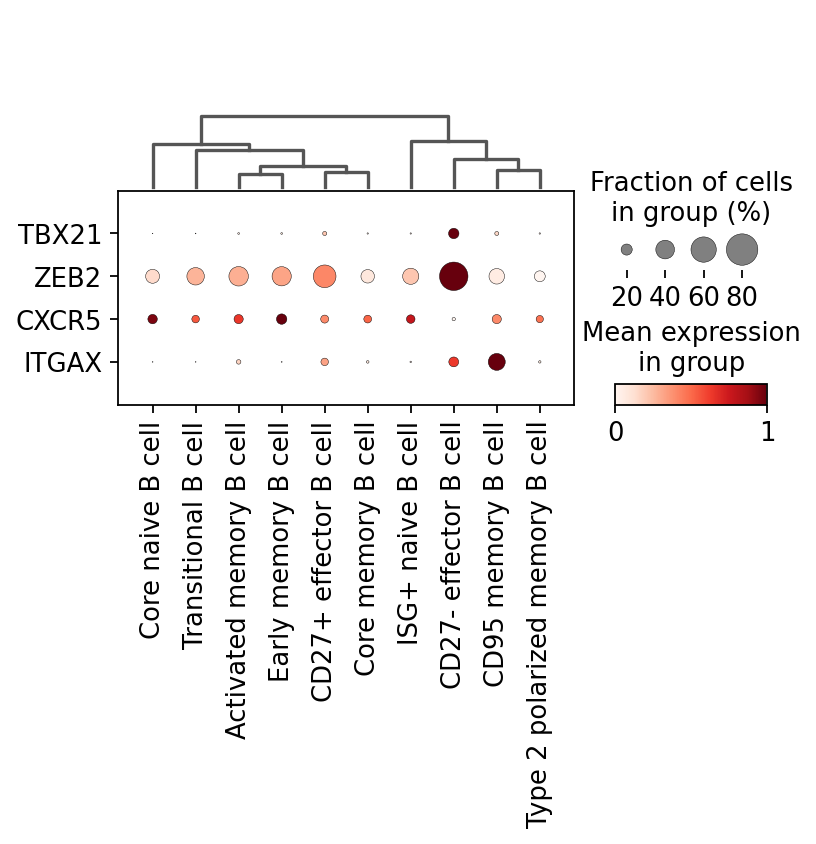

In [ ]:
sc.pl.dotplot(
    B_adata,
    ["TBX21", "ZEB2", "CXCR5", "ITGAX"],
    groupby="AIFI_L3_new",
    standard_scale="var",
    dendrogram=True,
    swap_axes=True,
    save="_" + proj_name + "_b_cell_marker_genes_dotplot_scale_ARI.pdf",
)

In [ ]:
# calculate the b cell counts
# total_counts=Bmem_adata.obs.groupby(['sample.sampleKitGuid']).size().reset_index(name='bmem_counts')
b_cell_counts = (
    joint_adata_fl.obs.loc[joint_adata_fl.obs["AIFI_L1"] == "B cell", :]
    .groupby(["sample.sampleKitGuid"])
    .size()
    .reset_index(name="total_b_counts")
    .set_index("sample.sampleKitGuid")
)
b_cell_counts.head()

In [ ]:
# add b cell counts into the metadata
joint_adata_fl.obs = joint_adata_fl.obs.merge(
    b_cell_counts, how="left", left_on="sample.sampleKitGuid", right_index=True
)
joint_adata_fl

In [ ]:
# seperate out the mem b cells
Bmem_adata = joint_adata_fl[
    joint_adata_fl.obs["AIFI_L3_new"].str.contains("memory B|effector B"), :
].copy()

In [ ]:
Bmem_adata.obs["AIFI_L3_new"].unique().tolist()

In [ ]:
# save data
Bmem_adata.write_h5ad(data_path + "ALTRA_scRNA_Bmem_cells_certPro.h5ad")

## run normalization and clustering


In [ ]:
# load data
Bmem_adata = sc.read_h5ad(data_path + "ALTRA_scRNA_Bmem_cells_certPro.h5ad")

In [ ]:
Bmem_adata.obs["sample.sampleKitGuid"].unique()

In [ ]:
Bmem_adata

In [ ]:
# save the raw counts
Bmem_adata.layers["counts"] = Bmem_adata.X.copy()

In [ ]:
# mitochondrial genes
Bmem_adata.var["mt"] = Bmem_adata.var_names.str.startswith("MT-")
# ribosomal genes
Bmem_adata.var["ribo"] = Bmem_adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
Bmem_adata.var["hb"] = Bmem_adata.var_names.str.contains(("^HB[^(P)]"))
sc.pp.calculate_qc_metrics(
    Bmem_adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)

In [ ]:
# cpm normalization
sc.pp.normalize_total(Bmem_adata, target_sum=1e4, inplace=True)
sc.pp.log1p(Bmem_adata)

In [ ]:
# %%time
sc.pp.highly_variable_genes(Bmem_adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

In [ ]:
Bmem_adata.raw = Bmem_adata

In [ ]:
Bmem_adata

In [ ]:
sc.pp.scale(Bmem_adata, max_value=10)

In [ ]:
# setting highly variable as highly deviant to use scanpy 'use_highly_variable' argument in sc.pp.pca
sc.pp.pca(Bmem_adata, svd_solver="arpack", use_highly_variable=True)

In [ ]:
sc.pl.pca_scatter(Bmem_adata, color=["pct_counts_ribo", "pct_counts_mt"])

In [ ]:
# # setting highly variable as highly deviant to use scanpy 'use_highly_variable' argument in sc.pp.pca
# sc.pp.pca(Bmem_adata, svd_solver="arpack", use_highly_variable=True)

In [ ]:
# plot the principle component variance explained
sc.pl.pca_variance_ratio(Bmem_adata, log=True)

In [ ]:
sc.pp.neighbors(Bmem_adata, n_neighbors=15, n_pcs=15, use_rep="X_pca")
sc.tl.umap(Bmem_adata)

In [ ]:
# save the pre-harmonaized umap
Bmem_adata.obsm["X_orignial_umap"] = Bmem_adata.obsm["X_umap"].copy()

In [ ]:
# run harmony
import scanpy.external as sce

sce.pp.harmony_integrate(Bmem_adata, ["file.batchID"], adjusted_basis="X_pca_harmony")
sc.pp.neighbors(Bmem_adata, n_neighbors=15, n_pcs=30, use_rep="X_pca_harmony")
sc.tl.umap(Bmem_adata)
Bmem_adata.obsm["X_harmony_umap"] = Bmem_adata.obsm["X_umap"].copy()

In [ ]:
sc.pl.pca_loadings(Bmem_adata, components="1,2,3")

In [ ]:
# run clusters
sc.tl.leiden(Bmem_adata, key_added="leiden_0_5", resolution=0.5)
# run clusters
sc.tl.leiden(Bmem_adata, key_added="leiden_0_8", resolution=0.8)
# run clusters
sc.tl.leiden(Bmem_adata, key_added="leiden_1", resolution=1)

In [ ]:
# run clusters
sc.tl.leiden(Bmem_adata, key_added="leiden_1_2", resolution=1.2)

In [ ]:
sc.pl.umap(
    Bmem_adata,
    legend_loc="on data",
    color=["leiden_0_5", "leiden_0_8", "leiden_1", "leiden_1_2"],
    ncols=2,
    save=proj_name + "_cluster_umap.png",
)

In [ ]:
sc.pl.umap(
    Bmem_adata,
    legend_loc="on data",
    color=["CD40", "TLR9"],
    ncols=2,
    save=proj_name + "_cluster_umap.png",
)

In [ ]:
sc.pl.umap(
    Bmem_adata,
    legend_loc="on data",
    color=[
        "file.batchID",
        "subject.biologicalSex",
        "subject.subjectGuid",
        "AIFI_L2",
        "leiden_1",
        "AIFI_L3_new",
    ],
    ncols=3,
    save=proj_name + "_rna_cluster_labels_umap.png",
)

In [ ]:
# test for top genes that seperate the cells
cluster_name = "leiden_1"
sc.tl.rank_genes_groups(
    Bmem_adata,
    groupby=cluster_name,
    method="wilcoxon",
    key_added="leiden_1_wilcoxon_test",
)

In [ ]:
sc.pl.rank_genes_groups(
    Bmem_adata, n_genes=10, sharey=False, key="leiden_1_wilcoxon_test"
)

In [ ]:
leiden_deg = sc.get.rank_genes_groups_df(
    Bmem_adata, key="leiden_1_wilcoxon_test", pval_cutoff=None, group=None
).rename({"group": cluster_name}, axis="columns")
leiden_deg

In [ ]:
# remove cluster 14 and unknown population from the dataset
Bmem_adata_remove = Bmem_adata[
    (Bmem_adata.obs["leiden_1"] == "14")
    | (
        Bmem_adata.obs["AIFI_L3_new"].isin(
            ["Early memory B cell_uk1", "Activated memory B cell_uk1"]
        )
    )
]
Bmem_adata_remove

In [ ]:
Bmem_adata = Bmem_adata[~Bmem_adata.obs.index.isin(Bmem_adata_remove.obs.index)].copy()
Bmem_adata

In [ ]:
# save data
Bmem_adata.write_h5ad(data_path + "ALTRA_scRNA_Bmem_cells_filtered_certPro.h5ad")

### upload data to HISE

In [1]:
import hisepy as hp

In [2]:
?hp.upload.upload_files

Signature:
hp.upload.upload_files(
    files: list,
    study_space_id: str = None,
    project: str = None,
    title: str = None,
    input_file_ids: list = [],
    input_sample_ids: list = [],
    file_types: list = [],
    store: str = None,
    destination: str = '',
    do_prompt: bool = True,
)
Docstring:
Uploads files to a store and records their provenance in HISE, but V3

Parameters:
    files (list): absolute filepath of file to be uploaded
    study_space_id (str): ID that pertains to a study in the collaboration space (optional)
    project (str): project short name (required if study space is not specified, defaults to the ide's default setting
    title (str): 10+ character title for upload result 
    input_file_ids (list): fileIds from HISE that were utilized to generate a user's result
    input_sample_ids (list): sampleIds from HISE that were utilized to generate a user's result
    file_types (str): filetype of uploaded files 
    store (str): Which store ('project'

In [6]:
# upload file to hise
hp.upload.upload_files(do_conda_build_check=True
    files=[
        "/home/workspace/data/ALTRA_manusript/ALTRA_scRNA_Bmem_cells_certPro.h5ad",
        "/home/workspace/data/ALTRA_manusript/ALTRA_scRNA_Bmem_cells_filtered_certPro.h5ad",
    ],
    study_space_id="223de760-9624-45bd-aefe-ca24c75b1800",
    title="AlTRA scRNA Memory B cells h5ad objects",
    input_file_ids=["609f7543-d4d5-41e9-a3d2-8e50c3e7c61d"],
    destination="certpro",
)

{'Message': 'General Okay-ness',
 'VisualizationId': '00000000-0000-0000-0000-000000000000',
 'AbstractionId': '00000000-0000-0000-0000-000000000000',
 'TraceId': '302cbf82-04e4-4daa-ab44-b35bc013882d',
 'ProcessId': 'd33ca73f-3f9c-443c-b375-1d739e63f88d',
 'WorkflowId': '45048cd3-4b7a-4141-a626-350c9865c232',
 'FileIds': ['ebd0a762-0c6a-4145-ba6a-a942baee9ca7',
  '8ff3d9b3-c177-4594-a743-95378b16c16d']}

# Session Info


In [32]:
import sinfo

sinfo.sinfo(write_req_file=False)

-----
anndata     0.11.3
h5py        3.12.1
hisepy      0.3.0
matplotlib  3.10.0
numpy       1.24.3
pandas      2.2.3
scanpy      1.10.4
scipy       1.15.1
seaborn     0.13.2
sinfo       0.3.1
-----
IPython             8.30.0
jupyter_client      8.6.3
jupyter_core        5.7.2
-----
Python 3.11.9 | packaged by conda-forge | (main, Apr 19 2024, 18:36:13) [GCC 12.3.0]
Linux-6.6.87+-x86_64-with-glibc2.35
64 logical CPU cores, x86_64
-----
Session information updated at 2025-08-02 17:01
